In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('MetObjects.csv', low_memory=False)


print("Total artworks:", df.shape[0])
print("Total columns:", df.shape[1])

Total artworks: 448203
Total columns: 43


In [4]:
import zipfile

with zipfile.ZipFile('MetObjects.csv.zip', 'r') as zip_ref:
    zip_ref.extractall('')

print("Done!")

Done!


In [14]:
df.head()

,Object Number,Is Highlight,Is Public Domain,Object ID,Department,Object Name,Title,Culture,Period,Dynasty,...,Subregion,Locale,Locus,Excavation,River,Classification,Rights and Reproduction,Link Resource,Metadata Date,Repository
0,1979.486.1,False,False,1,American Decorative Arts,Coin,One-dollar Liberty Head Coin,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Metal,NaN,http://www.metmuseum.org/art/collection/search/1,4/3/2017 8:00:08 AM,"Metropolitan Museum of Art, New York, NY"
1,1980.264.5,False,False,2,American Decorative Arts,Coin,Ten-dollar Liberty Head Coin,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Metal,NaN,http://www.metmuseum.org/art/collection/search/2,4/3/2017 8:00:08 AM,"Metropolitan Museum of Art, New York, NY"
2,67.265.9,False,False,3,American Decorative Arts,Coin,Two-and-a-Half Dollar Coin,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Metal,NaN,http://www.metmuseum.org/art/collection/search/3,4/3/2017 8:00:08 AM,"Metropolitan Museum of Art, New York, NY"
3,67.265.10,False,False,4,American Decorative Arts,Coin,Two-and-a-Half Dollar Coin,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Metal,NaN,http://www.metmuseum.org/art/collection/search/4,4/3/2017 8:00:08 AM,"Metropolitan Museum of Art, New York, NY"
4,67.265.11,False,False,5,American Decorative Arts,Coin,Two-and-a-Half Dollar Coin,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Metal,NaN,http://www.metmuseum.org/art/collection/search/5,4/3/2017 8:00:08 AM,"Metropolitan Museum of Art, New York, NY"


# Metropolitan Museum of Art - Exploratory Data Analysis

## About the Dataset
This dataset contains over 448,000 artworks from The Met in New York City.
It includes information about departments, artists, mediums, and dates.

## Goal
Explore the collection to understand its composition and diversity.

In [15]:

missing = df.isnull().sum()
missing_percent = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_percent
}).sort_values('Percentage', ascending=False)

print(missing_df[missing_df['Missing Values'] > 0])

                         Missing Values  Percentage
River                            446100       99.53
County                           445715       99.44
Locus                            441264       98.45
State                            439843       98.13
Artist Suffix                    437991       97.72
Reign                            437386       97.59
Locale                           433108       96.63
Excavation                       432684       96.54
Portfolio                        427833       95.46
Subregion                        426487       95.15
Rights and Reproduction          425228       94.87
Dynasty                          425185       94.86
City                             417683       93.19
Region                           417125       93.07
Geography Type                   389740       86.96
Period                           376321       83.96
Country                          373753       83.39
Artist Prefix                    359275       80.16
Culture     

In [16]:

cols_to_keep = [
    'Department', 'Object Name', 'Title', 'Culture',
    'Artist Display Name', 'Artist Nationality',
    'Object Date', 'Object Begin Date', 'Object End Date',
    'Medium', 'Classification', 'Country', 'Is Highlight', 'Is Public Domain'
]

df_clean = df[cols_to_keep].copy()

print("Clean dataset shape:", df_clean.shape)
df_clean.head()

Clean dataset shape: (448203, 14)


,Department,Object Name,Title,Culture,Artist Display Name,Artist Nationality,Object Date,Object Begin Date,Object End Date,Medium,Classification,Country,Is Highlight,Is Public Domain
0,American Decorative Arts,Coin,One-dollar Liberty Head Coin,NaN,James Barton Longacre,American,1853,1853,1853,Gold,Metal,NaN,False,False
1,American Decorative Arts,Coin,Ten-dollar Liberty Head Coin,NaN,Christian Gobrecht,NaN,1901,1901,1901,Gold,Metal,NaN,False,False
2,American Decorative Arts,Coin,Two-and-a-Half Dollar Coin,NaN,NaN,NaN,1909–27,1909,1927,Gold,Metal,NaN,False,False
3,American Decorative Arts,Coin,Two-and-a-Half Dollar Coin,NaN,NaN,NaN,1909–27,1909,1927,Gold,Metal,NaN,False,False
4,American Decorative Arts,Coin,Two-and-a-Half Dollar Coin,NaN,NaN,NaN,1909–27,1909,1927,Gold,Metal,NaN,False,False


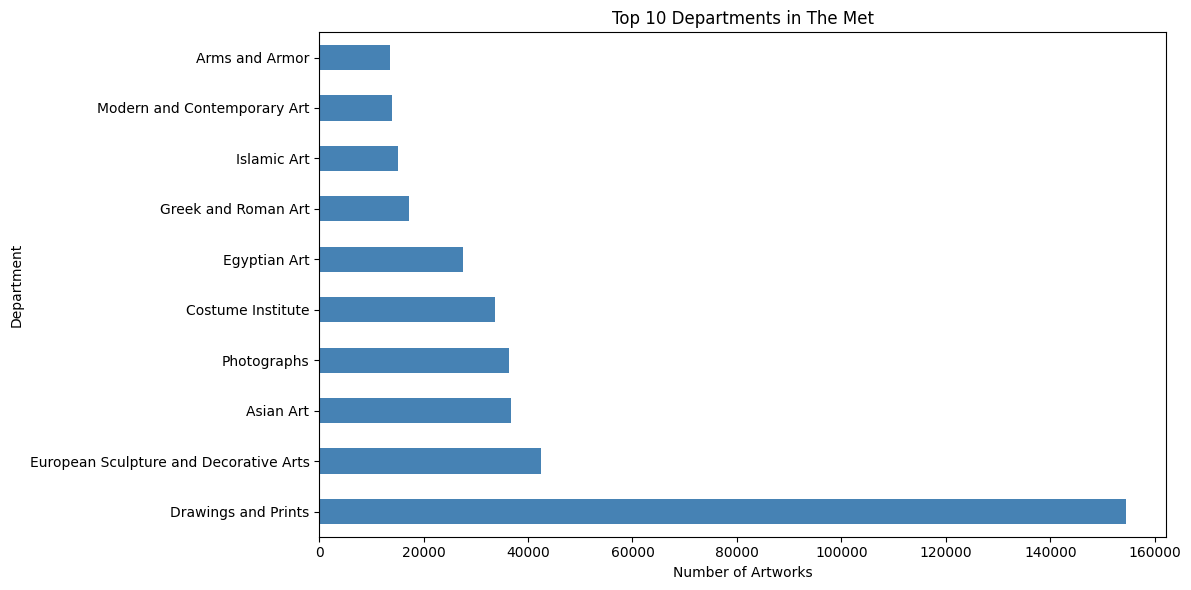

In [17]:

plt.figure(figsize=(12, 6))
df_clean['Department'].value_counts().head(10).plot(kind='barh', color='steelblue')
plt.title('Top 10 Departments in The Met')
plt.xlabel('Number of Artworks')
plt.tight_layout()
plt.show()

## 1. Top 10 Departments
The Met's collection is dominated by Drawings and Prints with over 150,000 artworks,
followed by European Sculpture and Asian Art. Islamic Art also has a strong presence.

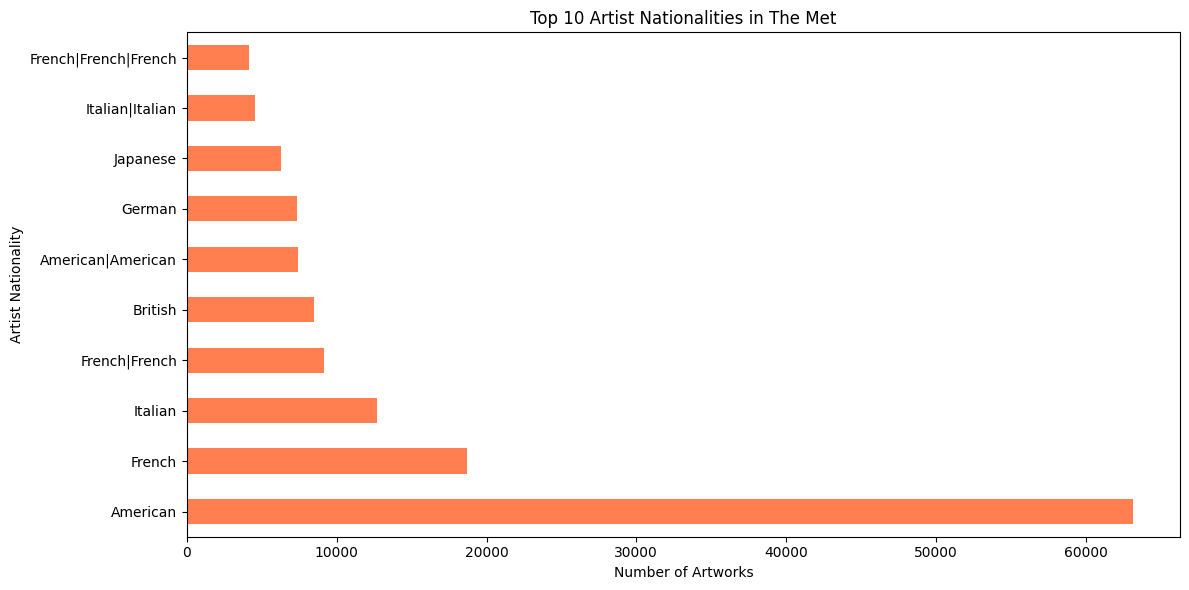

In [18]:

plt.figure(figsize=(12, 6))
df_clean['Artist Nationality'].value_counts().head(10).plot(kind='barh', color='coral')
plt.title('Top 10 Artist Nationalities in The Met')
plt.xlabel('Number of Artworks')
plt.tight_layout()
plt.show()

## 2. Top 10 Artist Nationalities
American artists lead the collection, reflecting the museum's location in New York City.
French and Italian artists follow, highlighting the strong European influence in the collection.

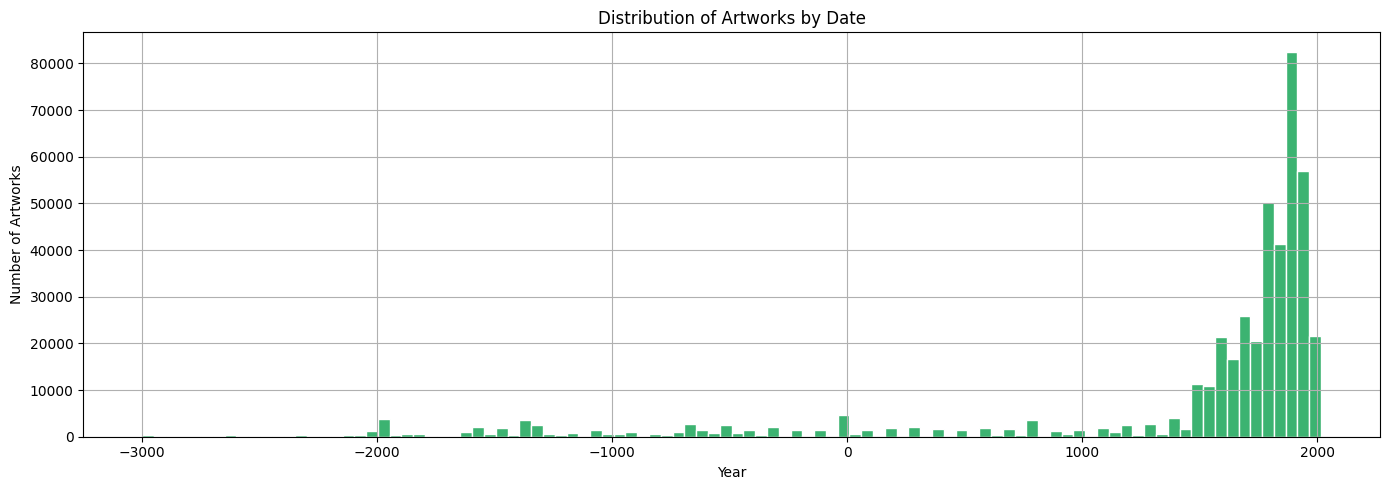

In [20]:

df_dates = df_clean[
    (df_clean['Object Begin Date'] >= -3000) &
    (df_clean['Object Begin Date'] <= 2024)
]['Object Begin Date'].dropna().astype(int)

plt.figure(figsize=(14, 5))
df_dates.hist(bins=100, color='mediumseagreen', edgecolor='white')
plt.title('Distribution of Artworks by Date')
plt.xlabel('Year')
plt.ylabel('Number of Artworks')
plt.tight_layout()
plt.show()

## 3. Distribution of Artworks by Date
The collection spans from 3000 BC to present day.
Most artworks date from 1800 onwards, with a significant spike in the modern era.

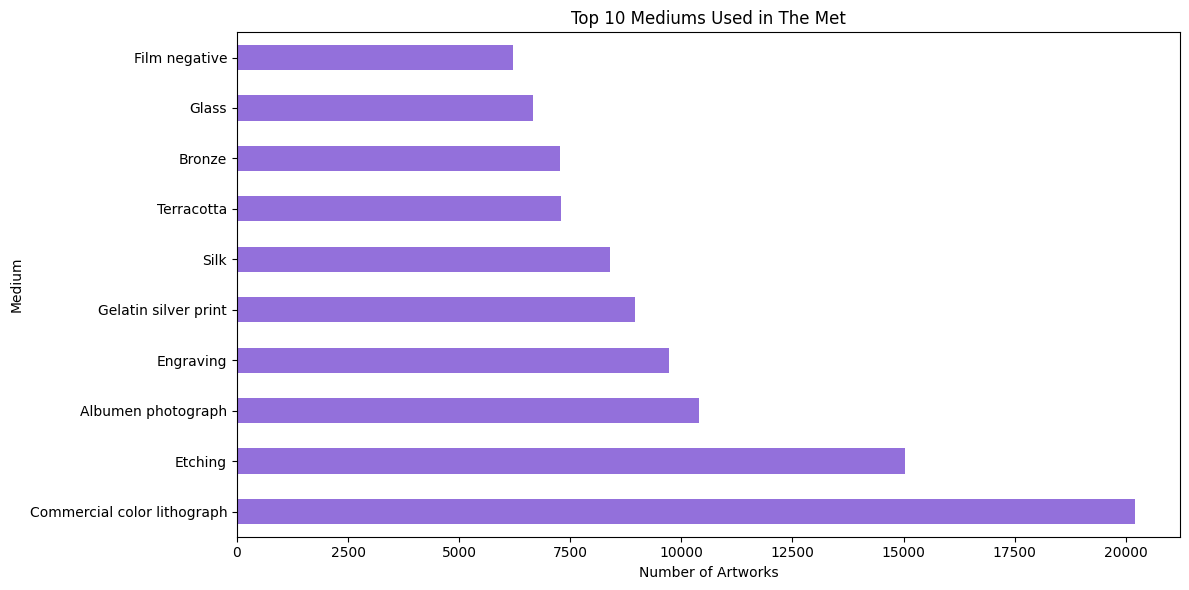

In [21]:

plt.figure(figsize=(12, 6))
df_clean['Medium'].value_counts().head(10).plot(kind='barh', color='mediumpurple')
plt.title('Top 10 Mediums Used in The Met')
plt.xlabel('Number of Artworks')
plt.tight_layout()
plt.show()

## 4. Top 10 Mediums
Commercial color lithograph dominates the collection, followed by traditional
techniques like etching and engraving. Silk represents the strong Asian and Islamic art presence.

## Key Findings

1. **Drawings and Prints** is the largest department with 150,000+ artworks
2. **American artists** dominate the collection (60,000+ artworks)
3. **Most artworks** were created after 1800, showing a modern focus
4. **Commercial lithograph** is the most common medium
5. **Islamic and Egyptian Art** have strong representation despite being non-Western

## Conclusions

The Met's collection reflects a strong Western bias, with American and European
artists dominating. However, the presence of Islamic, Egyptian, and Asian Art
departments shows the museum's effort toward global representation.

Future analysis could explore:
- Gender diversity among artists
- Geographic distribution of artworks
- How the collection grew over time by department